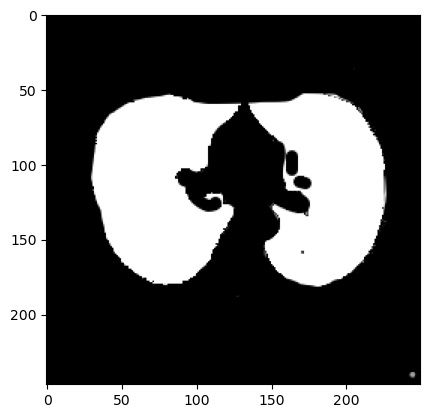

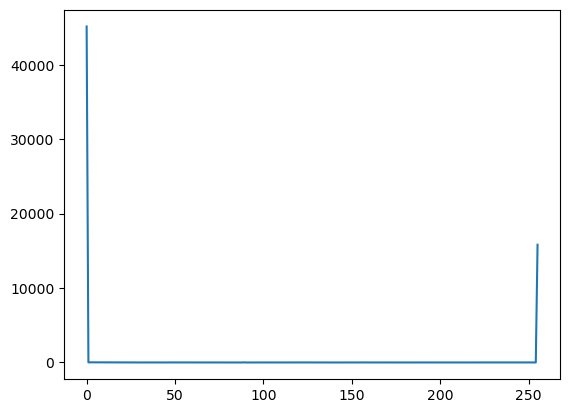

(247, 250)


In [41]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/CHEST.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

print(image.shape)

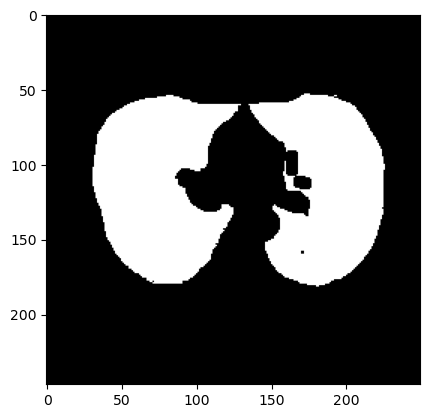

In [42]:
# Usando ahora dos semillas, utilice el algoritmo de crecimiento de regiones para segmentar de forma automática el área de los pulmones.
# Pruebe con varios valores de tolerancia

from skimage.segmentation import flood

# logica para sembrar mas de una semilla
semillas = [(80,80), (170,160)]

mascara_total = np.zeros_like(image, dtype=bool)

for s in semillas:
    mascara = flood(image, s, tolerance=10)
    mascara_total = mascara_total | mascara

# Visualizar imagen
mascara_total = mascara_total *255
plt.imshow(mascara_total, cmap="gray",  vmin=0, vmax=255)
plt.show()


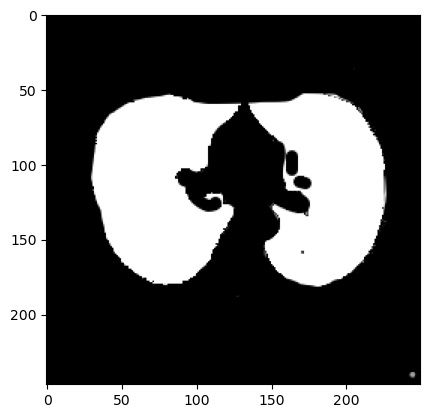

In [43]:
# Visualizar la imagen de paint
image_paint= cv2.imread("images/paint.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image_paint, cmap="gray",  vmin=0, vmax=255)
plt.show()


Compare ambos resultados. ¿Cómo se puede determinar cualitativamente dos regiones? ¿Cuál segmentación tiene mejor calidad?
Se puede determinar cualitativamente dos regiones por su forma, sus bordes que lo separan de otras regiones. La segmentación que tiene mejor calidad fue la que se generó con la función flood.

In [44]:
# Investigue el coeficiente de Sorensen-Dice. Esta es una medida de la similitud entre dos áreas segmentadas.
# Aplíquelo sobre las segmentaciones del punto 3 y 4.

import numpy as np

# Asegurar que sean booleanas
A = mascara_total.astype(bool)
B = image_paint.astype(bool)

# Intersección
interseccion = np.logical_and(A, B).sum()

# Tamaños
size_A = A.sum()
size_B = B.sum()

# Dice
dice = (2 * interseccion) / (size_A + size_B)

print("Coeficiente Dice:", dice)

Coeficiente Dice: 0.9763789227310523


¿Cómo puede interpretar el resultado? ¿Respalda el análisis cualitativo el valor obtenido?

Investigando, si el coefciente es de 1.0 son segmentos identicos, al tener el resultado 0.9763789227310523 quiere decir que son muy similares pero tienen algunas diferencias. Efectivamente respalda el analsis cualitativo porque tienen formas muy parecidas, es a un nivel mucho mas detallado a nivel de pixeles que hay diferencias y por eso tiene sentido el coeficiente 0.9763789227310523.